# MLOPS EDA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

df = pd.read_csv("mlops dataset/tech_mental_health_burnout.csv")

In [4]:
print("Dataset Shape: ", df.shape)
print("=" * 90)
print("Dataset Columns:")
print(df.columns)
print("=" * 90)
print("Dataset:")
df.head(3)

Dataset Shape:  (150000, 25)
Dataset Columns:
Index(['age', 'gender', 'job_role', 'experience_years', 'company_size',
       'work_mode', 'work_hours_per_week', 'overtime_hours',
       'meetings_per_day', 'deadlines_missed', 'job_satisfaction',
       'manager_support', 'work_life_balance', 'sleep_hours',
       'physical_activity_days', 'screen_time_hours', 'caffeine_intake',
       'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score',
       'depression_score', 'burnout_score', 'burnout_level',
       'seeks_professional_help'],
      dtype='object')
Dataset:


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0


In [5]:
print("Column Data Types:")
print("=" * 90)
print(df.dtypes)

Column Data Types:
age                          int64
gender                      object
job_role                    object
experience_years           float64
company_size                object
work_mode                   object
work_hours_per_week        float64
overtime_hours             float64
meetings_per_day           float64
deadlines_missed             int64
job_satisfaction           float64
manager_support            float64
work_life_balance          float64
sleep_hours                float64
physical_activity_days       int64
screen_time_hours          float64
caffeine_intake              int64
social_support_score       float64
has_therapy                  int64
stress_level               float64
anxiety_score              float64
depression_score           float64
burnout_score              float64
burnout_level               object
seeks_professional_help      int64
dtype: object


In [6]:
null_counts = df.isnull().sum()
print("Null Values Count:")
print(null_counts)

Null Values Count:
age                        0
gender                     0
job_role                   0
experience_years           0
company_size               0
work_mode                  0
work_hours_per_week        0
overtime_hours             0
meetings_per_day           0
deadlines_missed           0
job_satisfaction           0
manager_support            0
work_life_balance          0
sleep_hours                0
physical_activity_days     0
screen_time_hours          0
caffeine_intake            0
social_support_score       0
has_therapy                0
stress_level               0
anxiety_score              0
depression_score           0
burnout_score              0
burnout_level              0
seeks_professional_help    0
dtype: int64


In [7]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

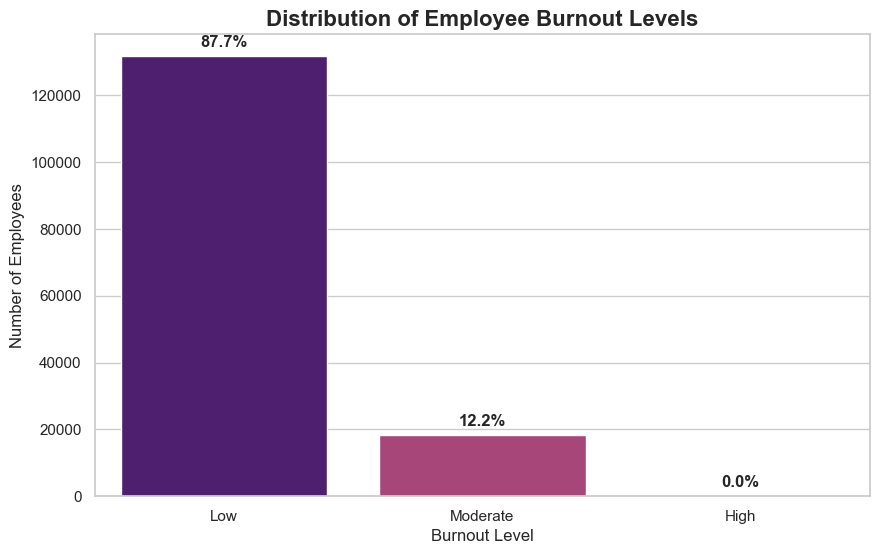

In [8]:
# Target Variable Distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='burnout_level', hue='burnout_level', data=df, order=['Low', 'Moderate', 'High'], palette='magma', legend=False)
plt.title('Distribution of Employee Burnout Levels', fontsize=16, fontweight='bold')
plt.xlabel('Burnout Level')
plt.ylabel('Number of Employees')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', weight='bold')
plt.show()


In [22]:
df['burnout_level'].value_counts()

burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64

## KEY INSIGHTS
- **87.7%** of employees report **low burnout**, suggesting that it is fairly healthy overall.
- **12.2%** report **moderate burnout**, making this group worth paying more attention to.
- **0%** currently report **high burnout**, which is a positive sign but means there is way too little data for the model to predict later on. Clear imbalance in data.
- Identifying employees in the moderate group early could help prevent their burnout from escalating further and becoming more serious.

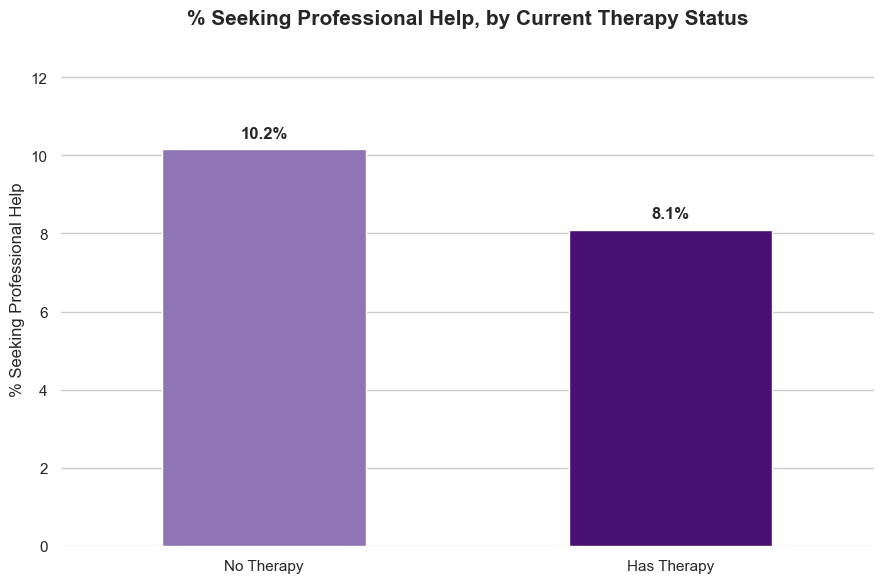

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

rates = df.groupby('has_therapy')['seeks_professional_help'].mean() * 100
rates.index = ['No Therapy', 'Has Therapy']

ax = sns.barplot(x=rates.index, y=rates.values, hue=rates.index,
                  palette=['#8E6BBE', '#4B0082'], legend=False, width=0.5)

for i, v in enumerate(rates.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.title('% Seeking Professional Help, by Current Therapy Status', fontsize=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('% Seeking Professional Help')
plt.ylim(0, max(rates.values) + 3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [24]:
print(pd.crosstab(df['has_therapy'], df['seeks_professional_help'], normalize='index') * 100)
print("\nCorrelation:", df['has_therapy'].corr(df['seeks_professional_help']))

seeks_professional_help          0          1
has_therapy                                  
0                        89.848660  10.151340
1                        91.911335   8.088665

Correlation: -0.030317460979826603


## KEY INSIGHTS

- Employees already in therapy are actually less likely to be flagged as seeking professional help, at 8.1% compared with 10.1% for those not in therapy. 

- The very weak correlation (-0.03) also shows that the two variables are not simply measuring the same thing. This suggests has_therapy is capturing whether an employee already has support, while seeks_professional_help reflects whether they are currently looking for support. Therefore, has_therapy can be kept as a predictor without being considered target leakage.

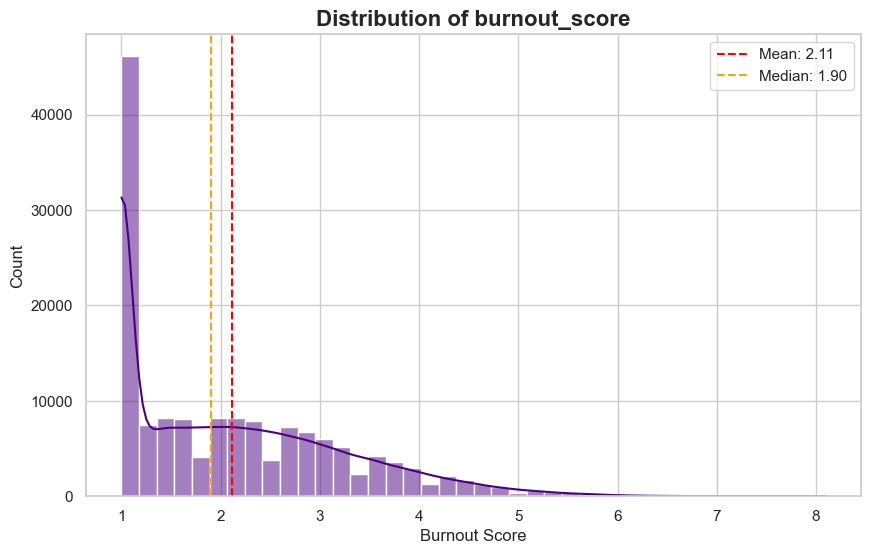

Skewness: 0.8907426593656792
Kurtosis: 0.15940594012319975


In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['burnout_score'], kde=True, color='#4B0082', bins=40)
plt.axvline(df['burnout_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['burnout_score'].mean():.2f}")
plt.axvline(df['burnout_score'].median(), color='orange', linestyle='--', label=f"Median: {df['burnout_score'].median():.2f}")
plt.title('Distribution of burnout_score', fontsize=16, fontweight='bold')
plt.xlabel('Burnout Score'); plt.ylabel('Count'); plt.legend()
plt.show()

print("Skewness:", df['burnout_score'].skew())
print("Kurtosis:", df['burnout_score'].kurt())

## KEY INSIGHTS

- The score is right-skewed (skew = 0.89), meaning most employees have scores between 1 and 2, with fewer employees scoring as high as 7–8. This also explains why the mean (2.11) is higher than the median (1.90), as the higher scores pull the average up.

- Since the kurtosis is close to zero, there are no unusually heavy tails or large groups of extreme values. Overall, the distribution shows a gradual decline rather than a clear group of outliers. This is why transformation=True and normalize=True in PyCaret can help make the data more suitable for models that work better with normally distributed features because they reduce skewness and scale the data so that extreme values have less influence, leading to more stable and accurate model performance.

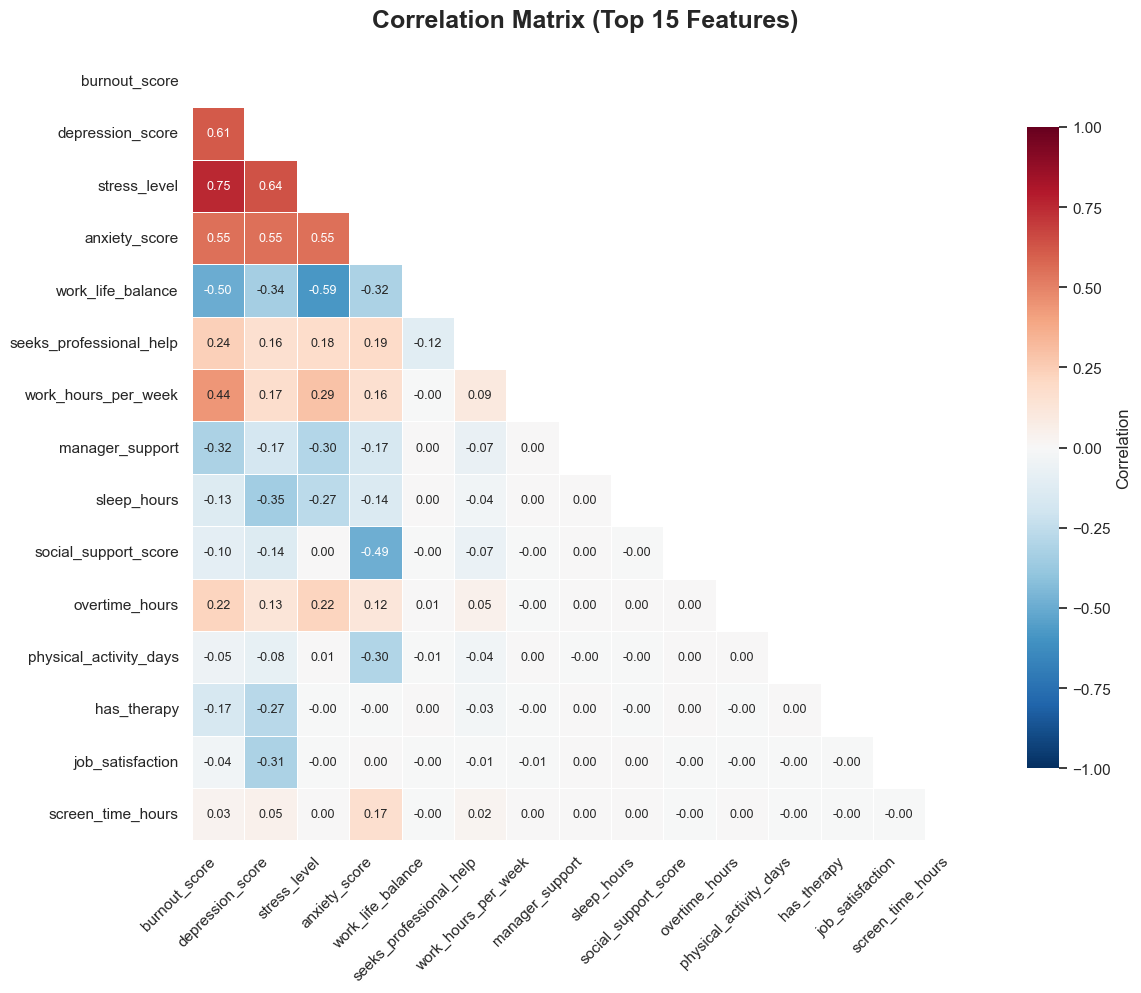

In [10]:
corr = df.select_dtypes(include=np.number).corr()

top_features = (
    corr.abs()
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .index
)

corr_top = corr.loc[top_features, top_features]
mask = np.triu(np.ones_like(corr_top, dtype=bool))

plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

sns.heatmap(
    corr_top,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"label": "Correlation", "shrink": 0.8}
)

plt.title(
    "Correlation Matrix (Top 15 Features)",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## KEY INSIGHTS

The correlation matrix shows that **stress, depression, and anxiety** are closely linked to burnout. Among these factors, **stress level (0.75)** has the strongest relationship with burnout, followed by **depression (0.61)** and **anxiety (0.55)**. **Working hours** and **Overtime** also play a moderate role, suggesting that having enough time to rest and recover is important.

> **Work-Life Balance:** **-0.50 correlation with burnout**  
> Employees with better work-life balance tend to report lower levels of burnout.

Interestingly, **manager support** also has a negative relationship with burnout. A common misconception is that more supervision means being watched more closely. However, the data suggests that employees who receive more support and guidance from their managers tend to experience less burnout.

In [11]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=['burnout_score'])
vif_data = pd.DataFrame({
    'feature': numeric_df.columns,
    'VIF': [variance_inflation_factor(numeric_df.values, i) for i in range(numeric_df.shape[1])]
})
print(vif_data.sort_values('VIF', ascending=False))

                    feature        VIF
15             stress_level  76.487001
16            anxiety_score  47.043375
2       work_hours_per_week  45.221750
9               sleep_hours  26.877761
17         depression_score  22.929824
11        screen_time_hours  18.147622
0                       age  15.966846
13     social_support_score  13.861434
6          job_satisfaction  10.907687
8         work_life_balance  10.672054
7           manager_support   9.143013
4          meetings_per_day   5.036241
3            overtime_hours   4.084546
1          experience_years   4.041150
10   physical_activity_days   3.726420
12          caffeine_intake   3.576753
5          deadlines_missed   1.805345
14              has_therapy   1.620095
18  seeks_professional_help   1.164443


## KEY INSIGHTS

- The VIF results show strong multicollinearity among several features. stress_level (76.5), anxiety_score (47.0) and work_hours_per_week (45.2) are well above the usual VIF threshold of 10. This means several features are providing similar information, which matches the patterns seen in the correlation heatmap.

- The key insight is that multicollinearity is still a concern despite PyCaret's settings. Although for example, let's say remove_multicollinearity is set to 0.9 to help remove highly correlated feature pairs, it may not catch cases where several moderately correlated features collectively create high multicollinearity.

In [12]:
X_leak = df[['stress_level', 'anxiety_score', 'depression_score']]
y_leak = df['burnout_score']
    
rf_leak = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf_leak, X_leak, y_leak, cv=5, scoring='r2')
print(f"Random Forest R2 (cross-validated): {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

lr_scores = cross_val_score(LinearRegression(), X_leak, y_leak, cv=5, scoring='r2')
print(f"Linear Regression R2 (cross-validated): {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")

Random Forest R2 (cross-validated): 0.5542 (+/- 0.0040)
Linear Regression R2 (cross-validated): 0.6077 (+/- 0.0021)


## KEY INSIGHTS

- The results suggest that burnout is strongly related to stress, anxiety, and depression, but is not simply calculated from them. 

- Linear Regression performed better (R² ≈ 0.61) than Random Forest (R² ≈ 0.55), suggesting the relationship is mostly linear rather than strongly nonlinear. 

- However, around 39–45% of the variation in burnout remains unexplained, indicating that other factors such as work hours, work-life balance, manager support, and sleep may also contribute to burnout.

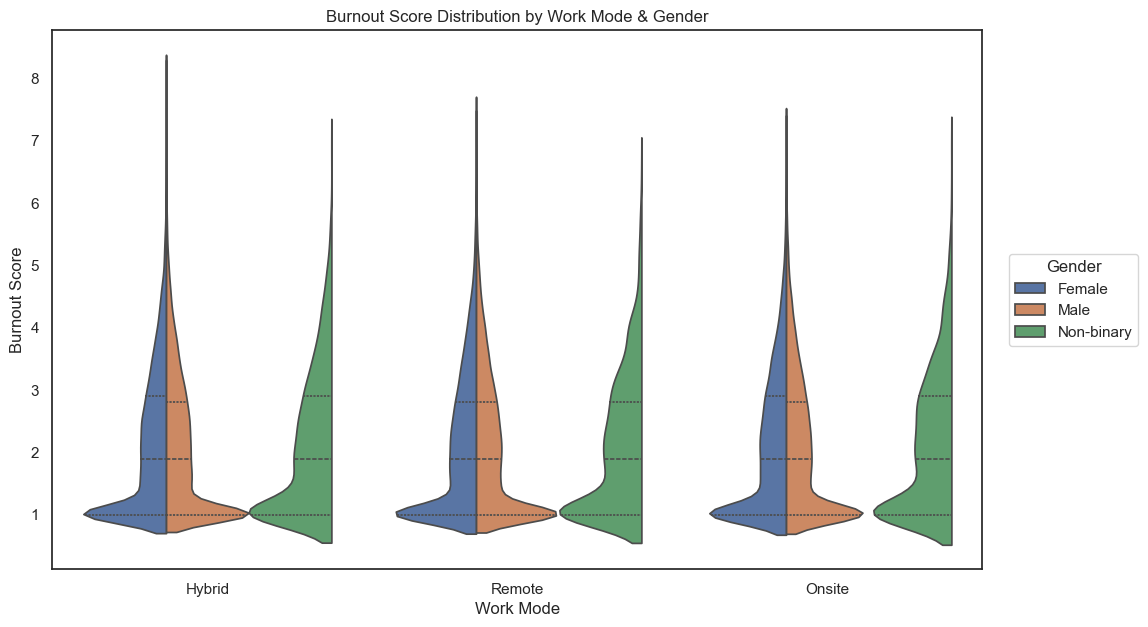

In [13]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='work_mode', y='burnout_score', data=df, hue='gender', split=True, inner="quart")
plt.title('Burnout Score Distribution by Work Mode & Gender')
plt.xlabel('Work Mode')
plt.ylabel('Burnout Score')
plt.legend(title='Gender', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.show()

## KEY INSIGHTS

The violin plot shows the distribution of burnout scores across different **work modes and genders**. The width of each violin represents the number of employees at each score, while the lines show the median and quartiles.

It is commonly expected that Remote workers would experience less burnout than Onsite workers. However, the **median scores and overall distributions are quite similar across all work modes**, suggesting that work mode may not have a major impact on burnout. Most employees are concentrated around the lower scores, although the violins extend to **7–8**, showing that **high burnout still exists in smaller numbers across all work modes**.

The distributions also look **very similar across genders**, with only small differences between Male, Female, and Non-binary employees. This suggests that gender does not have a strong relationship with burnout in this dataset. While there are some small differences in the moderate burnout range, they are not large enough to show a clear pattern.

For the ML model, this also suggests that **gender may not be an important predictor of burnout**. This is a good sign for model fairness, as the model is less likely to depend heavily on gender when making predictions.

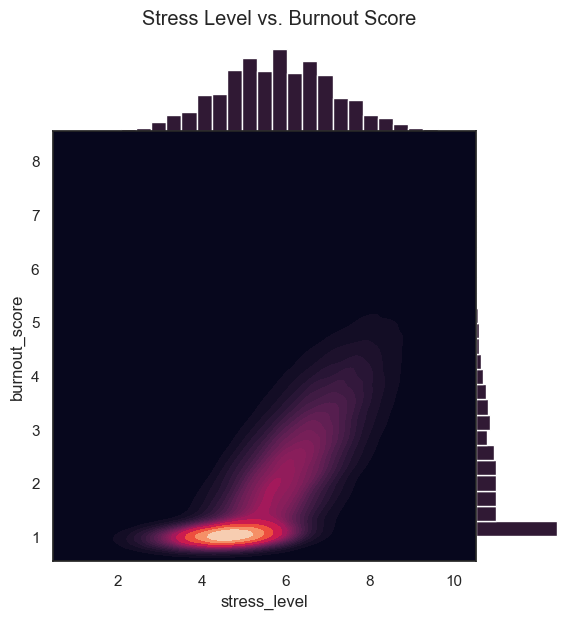

In [14]:
g = sns.JointGrid(data=df, x="stress_level", y="burnout_score", space=0)
g.plot_joint(sns.kdeplot, fill=True, cmap="rocket", thresh=0, levels=20)
g.plot_marginals(sns.histplot, color="#301934", alpha=1, bins=25)
g.fig.suptitle('Stress Level vs. Burnout Score', y=1.03)
plt.show()

In [15]:
print("Mean where stress_level > 6: ")
print(df.groupby(df['stress_level'] >= 6)['burnout_score'].mean())

Mean where stress_level > 6: 
stress_level
False    1.470184
True     2.896191
Name: burnout_score, dtype: float64


## KEY INSIGHTS

The density map shows that higher stress is linked to higher burnout. Employees with **stress levels below 6** have an average burnout score of **1.47**, while those with stress levels of **6 or above** have an average of **2.90**. This is a noticeable difference, showing that stress is an important factor when looking at burnout.

<Figure size 1200x1000 with 0 Axes>

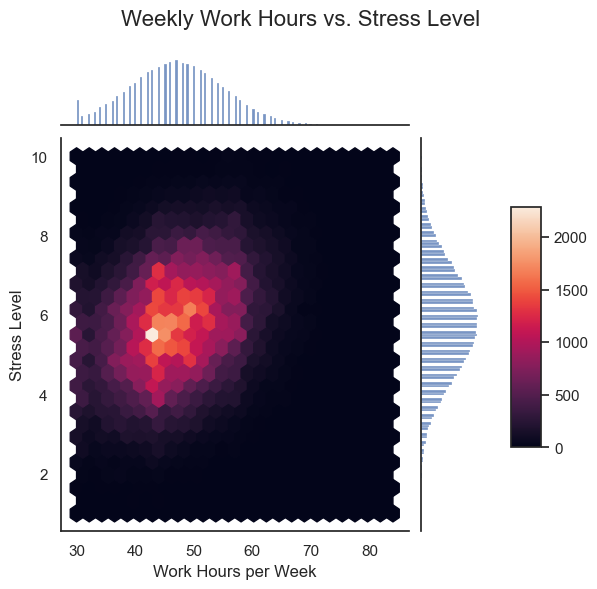

In [16]:
plt.figure(figsize=(12, 10))
g = sns.jointplot(data=df, x='work_hours_per_week', y='stress_level', 
                  kind='hex', cmap='rocket', gridsize=25)
plt.subplots_adjust(left=0.1, right=0.8, top=0.9)
cbar_ax = g.fig.add_axes([.85, .25, .05, .4])
plt.colorbar(cax=cbar_ax)
g.fig.suptitle('Weekly Work Hours vs. Stress Level', fontsize=16)
g.set_axis_labels('Work Hours per Week', 'Stress Level', fontsize=12)
plt.show()

In [17]:
print("Median: ", df['work_hours_per_week'].median())
print("=" * 90)
print("Mean where stress_level > 6: ")
print(df.groupby(df['stress_level'] >= 6)['burnout_score'].mean())
print("=" * 90)
print("Mean stress level for >60 work hours/week:")
print( df.groupby(df['work_hours_per_week'] >= 60)['stress_level'].mean())
print("=" * 90)
print("Mean burnout score for >60 work hours/week: ")
print(df.groupby(df['work_hours_per_week'] >= 60)['burnout_score'].mean())

Median:  47.0
Mean where stress_level > 6: 
stress_level
False    1.470184
True     2.896191
Name: burnout_score, dtype: float64
Mean stress level for >60 work hours/week:
work_hours_per_week
False    5.736231
True     6.573299
Name: stress_level, dtype: float64
Mean burnout score for >60 work hours/week: 
work_hours_per_week
False    2.044475
True     3.229469
Name: burnout_score, dtype: float64



## KEY INSIGHTS

The hexbin plot shows a similar pattern. The median work week is **47 hours**. Employees working **more than 60 hours** have a higher average stress level (**6.57**) compared to those working 60 hours or less (**5.74**). They also have a higher average burnout score (**3.23 vs. 2.04**). Overall, employees who work longer hours tend to report higher stress and burnout.

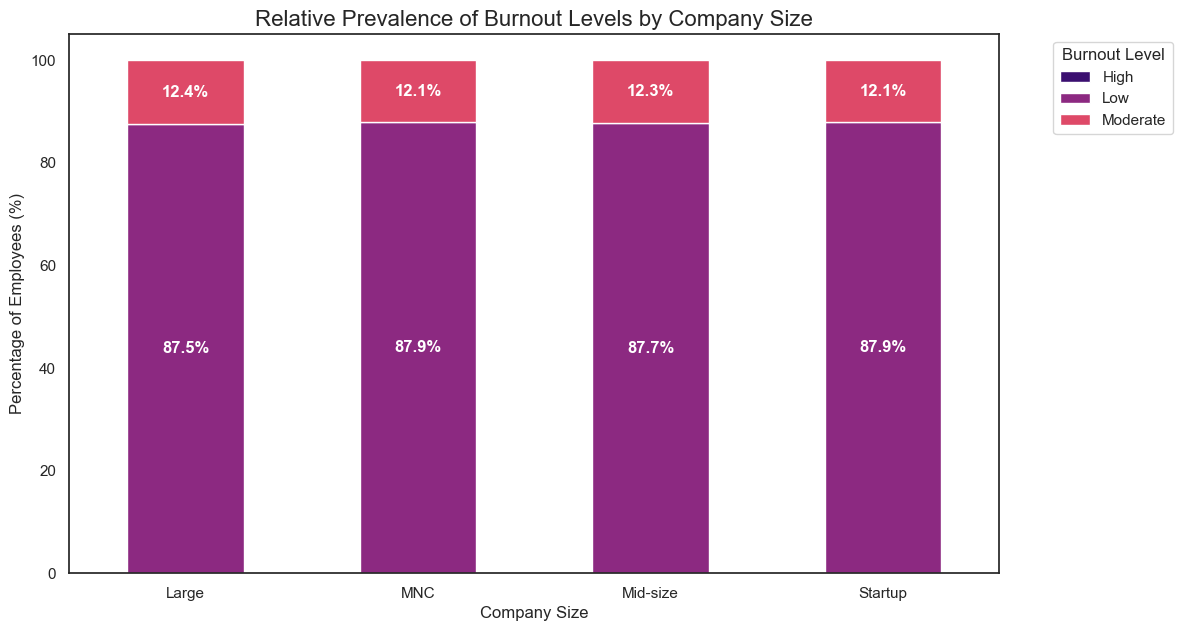

In [18]:
pivot_df = df.groupby(['company_size', 'burnout_level']).size().unstack()
pivot_df_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

ax = pivot_df_perc.plot(kind='bar', stacked=True, figsize=(12, 7), 
                        color=sns.color_palette("magma", 4))

plt.title('Relative Prevalence of Burnout Levels by Company Size', fontsize=16)
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Percentage of Employees (%)', fontsize=12)
plt.legend(title='Burnout Level', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', color='white', weight='bold')

plt.xticks(rotation=0)
plt.show()

## KEY INSIGHTS

- The burnout rates across different company sizes are quite similar. It was expected that startups would have noticeably higher burnout than larger companies, but the results show otherwise.

- **Startups had 12.1% moderate burnout**, while **large companies had 12.4%**. The small difference suggests that company size does not have a major impact on burnout in this dataset. Instead, burnout may be a broader issue across the tech industry rather than something limited to smaller or larger companies.

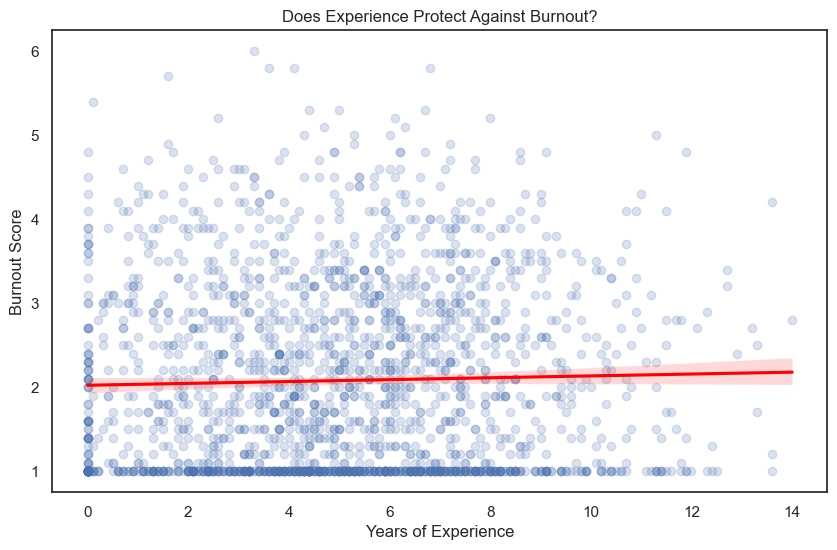

In [19]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(2000), x='experience_years', y='burnout_score', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Does Experience Protect Against Burnout?')
plt.xlabel('Years of Experience')
plt.ylabel('Burnout Score')
plt.show()

## KEY INSIGHTS

- The scatter plot shows that years of experience has little relationship with burnout. The regression line is almost flat, with employees across different experience levels showing a wide range of burnout scores.

- This suggests that having more or less experience does not strongly affect burnout in this dataset. An employee with 0 years of experience can have a similar burnout score to someone with 15 years of experience. Experience **may not be an important predictor** for the ML model.


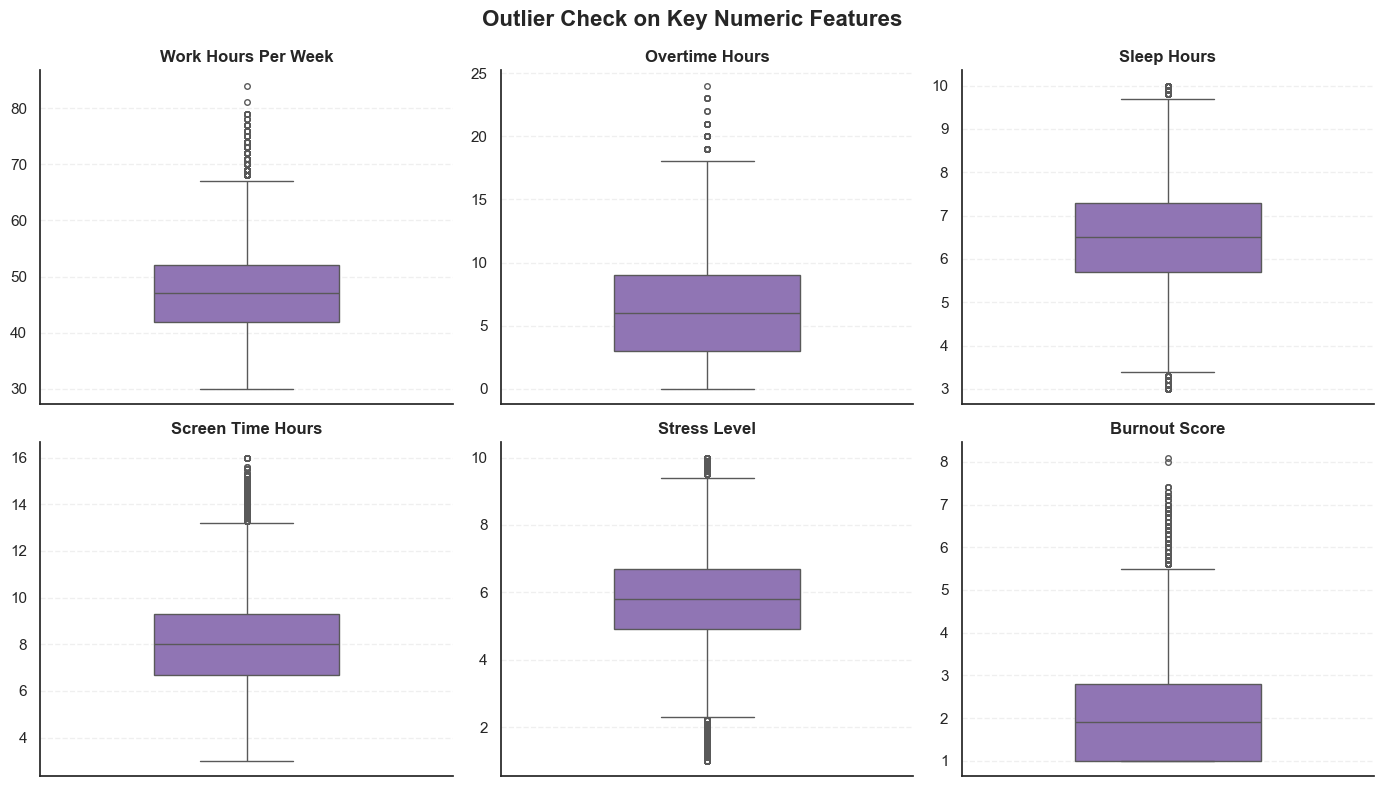

In [20]:
key_numeric = [
    'work_hours_per_week', 'overtime_hours', 'sleep_hours',
    'screen_time_hours', 'stress_level', 'burnout_score'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, key_numeric):
    sns.boxplot(y=df[col], ax=ax, width=0.45, color='#8E6BBE', fliersize=4)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Outlier Check on Key Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## KEY INSIGHTS

- Outliers appear reasonable, higher values in work_hours_per_week, overtime_hours, and screen_time_hours likely reflect employees working or using screens more, rather than data errors.

- sleep_hours and stress_level have relatively few outliers.

- Burnout scores naturally have a wider distribution, with the higher values following the right-skewed pattern seen earlier rather than forming a separate group of outliers.

- I think there is no need to remove rows, the outliers do not threaten the effectiveness of the model, so normalize and transformation should be enough to reduce their impact.

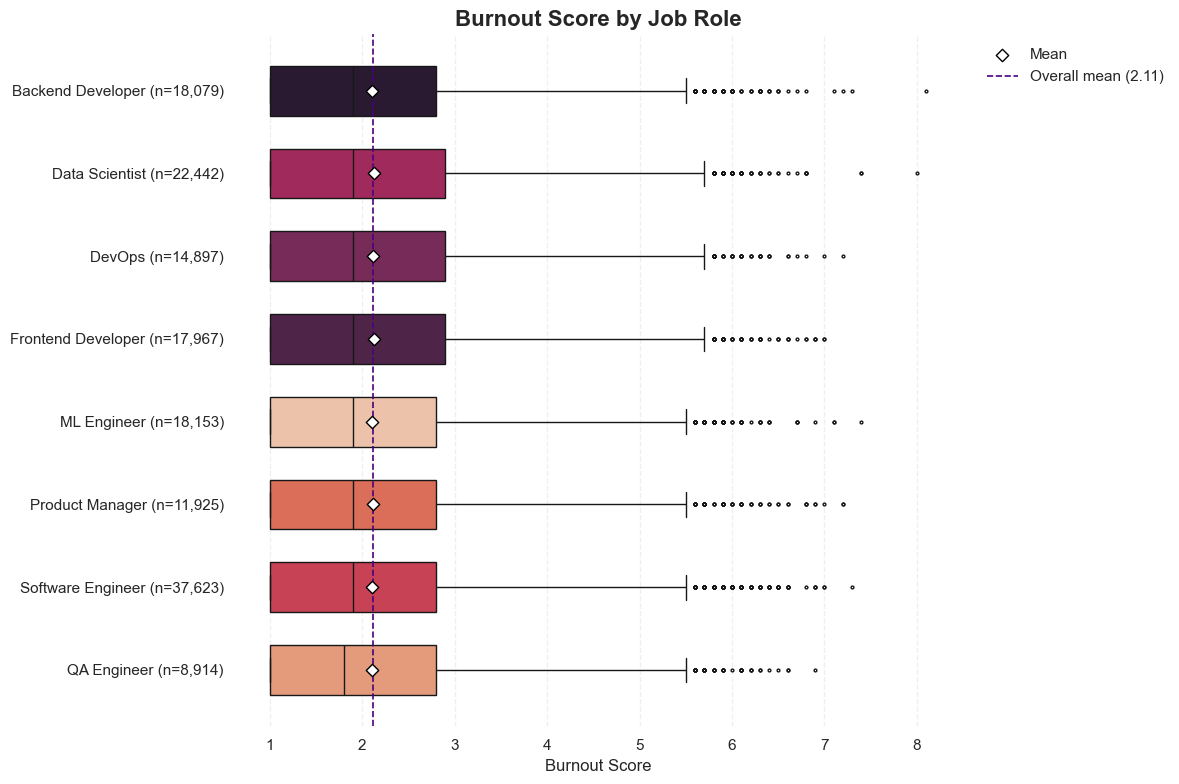

In [21]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

order = df.groupby('job_role')['burnout_score'].median().sort_values(ascending=False).index

ax = sns.boxplot(
    data=df, y='job_role', x='burnout_score', order=order,
    hue='job_role', palette='rocket', legend=False,
    width=0.6, fliersize=2, linewidth=1
)

means = df.groupby('job_role')['burnout_score'].mean().reindex(order)
ax.scatter(means, range(len(order)), marker='D', s=40,
           color='white', edgecolor='black', label='Mean', zorder=5)

counts = df['job_role'].value_counts().reindex(order)

ax.set_yticks(range(len(order)))
ax.set_yticklabels([f'{r} (n={counts[r]:,})' for r in order])

overall = df['burnout_score'].mean()
ax.axvline(overall, linestyle='--', linewidth=1.2,
           color='#4B0082', label=f'Overall mean ({overall:.2f})')

ax.set_title('Burnout Score by Job Role', fontsize=16, fontweight='bold')
ax.set_xlabel('Burnout Score')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)

ax.legend(loc='upper left',bbox_to_anchor=(1.02, 1),frameon=False)
plt.tight_layout()
plt.show()

## KEY INSIGHTS

- Job role shows very little difference in burnout, with all roles staying close to the overall mean of 2.11. Small difference between the highest and lowest means is also minor compared with the overall variation, so job role is unlikely to be a strong predictor of burnout.

- This shows that higher-level job roles are not necessarily more stressful or associated with higher burnout. In this dataset, burnout levels are fairly similar across job roles, suggesting that factors such as stress, anxiety, depression, and work hours may have a stronger influence than job seniority or role.